## Setup and Theory 
I will choose $\sigma^2$ to be 5.0 and generate data points $X$ of size $n \times p$ where $n=100$ and $p=10$ from a multivariate normal $$\mathcal{N}(0, I_p)$$.
Then I will compute the kernel matrix $K$ using the linear kernel formula, for all pairs of data points in $X$. 
so $K$ will look like:
$$K^{true}_{ij} = 5.0 \cdot X_i^T X_j$$
where $X_i$ and $X_j$ are the $i^{th}$ and $j^{th}$ rows of $X$ respectively.

After that, I will use our network with: 
$$K_{(i,j)}^{(k)} = K^{(k)}(f^{(k)}(x_i^{(k)}), f^{(k)}(x_j^{(k)}))$$

And then to get the entry $$K_{(i,j)}= \sum_{k=1}^{p} \alpha_k K_{(i,j)}^{(k)}$$

The learnable parameters will be $ K^{(k)}$. Later on we will navigate to learning the functional form of each $f^{(k)}$ as well. Alongide lookuing at learning $\alpha_k$ as well. Maybe even add a lasso regularization on $\alpha_k$ to promote sparsity, and so we might be able to start using this for feature selection as well. And so for now we will fix $\alpha_k = 1$ for all $k=1,...,p$. And fix $f^{(k)}$ to be the identity function for now (i.e. $f^{(k)}(x) = x$).

<!-- Now what I mean by $f^{(k)}$ is a learnable transformation from the k'th feature to some other space (i.e. $f^{(k)}: \mathbb{R} \rightarrow \mathbb{R}^{d_k}$ where $d_k=1$ for now). We will also fix this to be a non-linear of a linear transformation for this experiment (i.e. $f^{(k)}(x) = \tau (w_k x + b_k)$ where $w_k, b_k$ are learnable parameters), and $\tau$ is a non-linear activation function (ReLU, Tanh, Sigmoid, etc). (For this experiment I will choose $\tau=RelU$) -->

Now what I mean by $K^{(k)}$ is learning the parameters of the kernel function (which in this case is the linear kernel). So for the linear kernel we have:
$$K^{(k)}(X_i,X_j) = \sigma_k^2 X_i^{(k)} X_j^{(k)}$$
where $\sigma_k^2$ is a learnable parameter.

So in short the learnable parameters are:
- $\sigma_k^2$ for $k=1,...,p$ which I am gonna initialize using a $\mathcal{N}(1.0, 0.1)$

**IMPORTANT NOTE** about adding noise to the kernel matrix:
In this case I added two types of noise: 
* Adding noise to the diagonal only (i.e. $K^{true}_{observed} = K^{true} + diag(e)$ where $e \sim \mathcal{N}(0, \sigma_{noise}^2 I_n)$)
* Adding noise to every entry (i.e. $K^{true}_{observed} = K^{true} + N$ where $N_{ij} \sim \mathcal{N}(0, \sigma_{noise}^2)$ i.i.d)
* Of course adding on the diagnoal only will perform better. Also note that perturbing X directly won't have any effect on the learning since we are trying to learn the mapping of the kernel matrix and not the data points themselves (so in simple terms I do not care where X is coming from, I only care about the kernel matrix that is computed from X). So adding noise to X will only change the kernel matrix but won't add any useful information for the learning process. 
* Maybe what would be interesting here is to add noise to X but keep the kernel matrix fixed (i.e. not changing it according to the perturbed X) and see how that affects the learning process. But I will leave that for future work.


Now for the objective function we will minimize the Frobenius norm between the true kernel matrix and the learned kernel matrix:
$$L = ||K^{true}_{observed} - K||_F^2$$
**BUT** since the Frobenius norm results in very large values and makes the training unstable, I will minimize the mean squared error between the two matrices instead:
$$L = \frac{1}{n^2} \sum_{i=1}^{n} \sum_{j=1}^{n} (K^{true}_{observed,ij} - K_{ij})^2$$
**NOTE**: we do not care to compute the loss on all entries of ther kernel matrix, since by construction the kernel matrix is symmetric and positive definite. So we can compute the loss on the upper triangular part of the matrix only (including the diagonal). But for simplicity I will compute the loss on all entries for now.

## results anlysis
* As we increase the noise level, as expected the learning performance degrades. The model struggles to accurately recover the true kernel matrix when the noise level is high.
* When noise is added to the diagonal only, the model performs significantly better compared to when noise is added to every entry. Which is expected 
* The learned $\sigma_k^2$ values converge close to the true value of 5.0, especially when the noise level is low. And we tend to see that for learning the linear kernel, we are getting the predicted $\sigma_k^2$ values close to the true value(are all somehow equal to 5.0). Which show us that indeed the model is learning the correct kernel parameters.
* notice that adding noise to X directly won't have any effect on the learning since we are trying to learn the mapping of the kernel matrix and not the data points themselves (so in simple terms I do not care where X is coming from, I only care about the kernel matrix that is computed from X). So adding noise to X will only change the kernel matrix but won't add any useful information for the learning process.

## How to run: 
* You can simply import the libraieis and run the cell that is Fast Training Loop the rest are just cells for illustration and understanding. 

In [2]:
import torch
import matplotlib.pyplot as plt

#### generation of data and true kernel matrix K_TRUE

In [ ]:
torch.manual_seed(0)
n = 100
p = 10
X = torch.distributions.multivariate_normal.MultivariateNormal(
    loc=torch.ones(p),
    covariance_matrix=torch.eye(p)
).sample((n,))  # (n, p)
true_sigma_square = 5.0

noise_sigma_square = 10
# K_TRUE is a n x n kernel matrix with linear kernel plus noise
noise = torch.distributions.Normal(0, noise_sigma_square).sample((n,))
K_TRUE = true_sigma_square * (X @ X.t()) # i.e. f(x) in y=f(x) + e
K_TRUE_observed = K_TRUE + torch.diag(noise)  #check below for not on the diagnoal# here assuming noise is added to the diagonal to make sure K is positive definite
print("K_TRUE:\n", K_TRUE)
print("K_TRUE_observed:\n", K_TRUE_observed)

#### Slow Training Loopp (Easy to look at but inefficient) #NOTE this is for only one noise just to showcase the training loop 

In [ ]:
sigmas_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p,1)).requires_grad_(True)

## Huperparameters
learning_rate = 0.001
epochs = 100
fb_loss = []
for epoch in range(epochs):
    K_pred = torch.zeros((n,n))
    for i in range(n):
        for j in range(n):
            K_ij = 0.0
            for k in range(p):
                K_ij_k = sigmas_pred[k]**2 *  X[i,k]  * X[j,k] 
                K_ij +=  K_ij_k
            K_pred[i,j] = K_ij 
    # compute the frobenius norm loss
    diff = K_TRUE - K_pred
    # fro_loss = torch.norm(diff, p='fro')**2 # for logging only
    # loss = (diff * diff).mean() # for optimization # because if I only take the sum then the loss will be very large and the gradients will explode
    mse_loss = (diff * diff).mean()
    fb_loss.append(mse_loss.item())
    # backpropagation
    mse_loss.backward()
    # update parameters
    with torch.no_grad():
        sigmas_pred -= learning_rate * sigmas_pred.grad
        # zero the gradients
        sigmas_pred.grad.zero_()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {mse_loss.item()}")

#### Fast Training Loop (Efficient but harder to look at) (#NOTE this is for multiple noise levels)

In [3]:
torch.manual_seed(0)
array_of_noise_sigma_square = [0.1,0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]  #  0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5
train_error_last_epoch_for_each_experiment_mse = []
train_error_last_epoch_for_each_experiment_fb = []
# plot this against the last train error 
for noise_sigma_square in array_of_noise_sigma_square:
    # nature 
    n = 200
    p = 10
    X = torch.distributions.multivariate_normal.MultivariateNormal(
        loc=torch.ones(p),
        covariance_matrix=torch.eye(p)
    ).sample((n,))  # (n, p)
    true_sigma_square = 5.0
    # K_TRUE is a n x n kernel matrix with linear kernel plus noise

    """Adding noise on the dianoal only"""
    noise = torch.distributions.Normal(0, noise_sigma_square).sample((n,))
    K_TRUE = true_sigma_square * (X @ X.t()) # i.e. f(x) in y=f(x) + e
    K_TRUE_observed = K_TRUE + torch.diag(noise) # here assuming noise is added to the diagonal to make sure K is positive definite
    """Adding noise on every entry (I.I.D)"""
    noise_matrix = torch.distributions.Normal(0, noise_sigma_square).sample((n,n))
    K_TRUE_observed = K_TRUE + noise_matrix
    
    
    # researcher 
    
    sigmas_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p,1)).requires_grad_(True)

    learning_rate = 0.001
    epochs = 1000
    losses_mse = []
    losses_fb = []
    for epoch in range(epochs):
        weights = sigmas_pred.T ** 2   # (1, p)
        K_pred = (X * weights) @ X.T # n x n (Note what X * weights is it takes each column of X (we have p columns) and multiply it by the corresponding weight (each column is of shape (n,1) and weights are of shpae (1,p)) so the result is (n,p) then we do regular matrix mult (n,p) @ (p,n) = (n,n)

        # ---- Frobenius loss and MSE ----
        diff = K_TRUE_observed - K_pred
        loss = (diff * diff).mean() # we minimize the mean squared error between the two matrices 
        #NOTE: I am not able to use the frobenius norm directly because it results in very large values and makes the training unstable
        fro_loss = torch.norm(diff, p='fro')**2 # for logging only
        losses_fb.append(fro_loss.item()) # for logging only #NOTE: add to this division by ||K|| ||K^|| to make it not explode 

        losses_mse.append(loss.item()) 
        # backpropagation
        loss.backward()
        # update parameters
        with torch.no_grad():
            sigmas_pred -= learning_rate * sigmas_pred.grad
            # zero the gradients
            sigmas_pred.grad.zero_()
        if epoch % 10 == 0:
            # print(f"Epoch {epoch}, Loss: {loss.item()}")
            pass
    print("Learned sigmas_pred:", sigmas_pred)
    train_error_last_epoch_for_each_experiment_mse.append(losses_mse[-1])
    train_error_last_epoch_for_each_experiment_fb.append(losses_fb[-1])

Learned sigmas_pred: tensor([[2.2360],
        [2.2361],
        [2.2361],
        [2.2361],
        [2.2361],
        [2.2360],
        [2.2360],
        [2.2361],
        [2.2359],
        [2.2361]], requires_grad=True)
Learned sigmas_pred: tensor([[2.2358],
        [2.2358],
        [2.2361],
        [2.2360],
        [2.2357],
        [2.2364],
        [2.2364],
        [2.2356],
        [2.2362],
        [2.2365]], requires_grad=True)
Learned sigmas_pred: tensor([[2.2357],
        [2.2360],
        [2.2359],
        [2.2358],
        [2.2367],
        [2.2360],
        [2.2350],
        [2.2361],
        [2.2360],
        [2.2363]], requires_grad=True)
Learned sigmas_pred: tensor([[2.2372],
        [2.2354],
        [2.2367],
        [2.2344],
        [2.2348],
        [2.2372],
        [2.2349],
        [2.2378],
        [2.2364],
        [2.2345]], requires_grad=True)
Learned sigmas_pred: tensor([[2.2367],
        [2.2368],
        [2.2354],
        [2.2379],
        [2.2346],
 

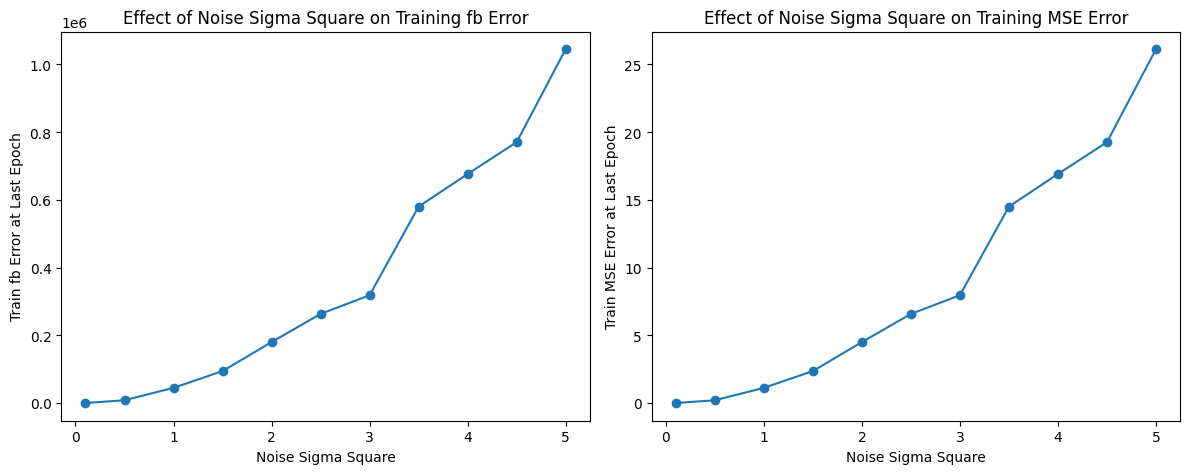

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: fb error ---
axes[0].plot(array_of_noise_sigma_square,
             train_error_last_epoch_for_each_experiment_fb,
             marker='o')
axes[0].set_xlabel('Noise Sigma Square')
axes[0].set_ylabel('Train fb Error at Last Epoch')
axes[0].set_title('Effect of Noise Sigma Square on Training fb Error')

# --- Right plot: MSE error ---
axes[1].plot(array_of_noise_sigma_square,
             train_error_last_epoch_for_each_experiment_mse,
             marker='o')
axes[1].set_xlabel('Noise Sigma Square')
axes[1].set_ylabel('Train MSE Error at Last Epoch')
axes[1].set_title('Effect of Noise Sigma Square on Training MSE Error')
plt.savefig('noise_vs_train_error_linear_kernel.png')
plt.tight_layout()
plt.show()

